# 🛡️ Phishing URL Detection — End-to-End Data Science Project

**Dataset:** PhiUSIIL Phishing URL Dataset  
**Goal:** Build a binary classification model to detect phishing URLs  
**Target Variable:** `label` (1 = Legitimate, 0 = Phishing)

---
## Project Pipeline
1. Data Loading & Overview
2. Exploratory Data Analysis (EDA)
3. Data Cleaning & Preprocessing
4. Feature Engineering
5. Model Building
6. Model Evaluation & Comparison
7. Hyperparameter Tuning
8. Final Model & Feature Importance
9. Insights & Conclusion

## 1. Setup & Library Imports

In [1]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, accuracy_score, f1_score, precision_score, recall_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.inspection import permutation_importance

# XGBoost
try:
    from xgboost import XGBClassifier
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False
    print('XGBoost not installed. Skipping.')

# Plotting style
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
COLORS = ['#2196F3', '#F44336']

print('✅ All libraries loaded successfully!')

XGBoost not installed. Skipping.
✅ All libraries loaded successfully!


## 2. Data Loading & Overview

In [2]:
# Load dataset
df = pd.read_csv('PhiUSIIL_Phishing_URL_Dataset.csv')

print(f'Dataset Shape: {df.shape}')
print(f'Total Records: {df.shape[0]:,}')
print(f'Total Features: {df.shape[1]}')
df.head()

Dataset Shape: (235795, 56)
Total Records: 235,795
Total Features: 56


,FILENAME,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,521848.txt,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,...,0,0,1,34,20,28,119,0,124,1
1,31372.txt,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,...,0,0,1,50,9,8,39,0,217,1
2,597387.txt,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,...,0,0,1,10,2,7,42,2,5,1
3,554095.txt,https://www.sfnmjournal.com,26,www.sfnmjournal.com,19,0,com,100.0,1.000000,0.522907,...,1,1,1,3,27,15,22,1,31,1
4,151578.txt,https://www.rewildingargentina.org,33,www.rewildingargentina.org,26,0,org,100.0,1.000000,0.079963,...,1,0,1,244,15,34,72,1,85,1


In [3]:
# Data types and basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 235795 entries, 0 to 235794
Data columns (total 56 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   FILENAME                    235795 non-null  object 
 1   URL                         235795 non-null  object 
 2   URLLength                   235795 non-null  int64  
 3   Domain                      235795 non-null  object 
 4   DomainLength                235795 non-null  int64  
 5   IsDomainIP                  235795 non-null  int64  
 6   TLD                         235795 non-null  object 
 7   URLSimilarityIndex          235795 non-null  float64
 8   CharContinuationRate        235795 non-null  float64
 9   TLDLegitimateProb           235795 non-null  float64
 10  URLCharProb                 235795 non-null  float64
 11  TLDLength                   235795 non-null  int64  
 12  NoOfSubDomain               235795 non-null  int64  
 13  HasObfuscation

In [4]:
# Statistical summary
df.describe().T.style.background_gradient(cmap='Blues')

,count,mean,std,min,25%,50%,75%,max
URLLength,235795.000000,34.573095,41.314153,13.000000,23.000000,27.000000,34.000000,6097.000000
DomainLength,235795.000000,21.470396,9.150793,4.000000,16.000000,20.000000,24.000000,110.000000
IsDomainIP,235795.000000,0.002706,0.051946,0.000000,0.000000,0.000000,0.000000,1.000000
URLSimilarityIndex,235795.000000,78.430778,28.976055,0.155574,57.024793,100.000000,100.000000,100.000000
CharContinuationRate,235795.000000,0.845508,0.216632,0.000000,0.680000,1.000000,1.000000,1.000000
TLDLegitimateProb,235795.000000,0.260423,0.251628,0.000000,0.005977,0.079963,0.522907,0.522907
URLCharProb,235795.000000,0.055747,0.010587,0.001083,0.050747,0.057970,0.062875,0.090824
TLDLength,235795.000000,2.764456,0.599739,2.000000,2.000000,3.000000,3.000000,13.000000
NoOfSubDomain,235795.000000,1.164758,0.600969,0.000000,1.000000,1.000000,1.000000,10.000000
HasObfuscation,235795.000000,0.002057,0.045306,0.000000,0.000000,0.000000,0.000000,1.000000


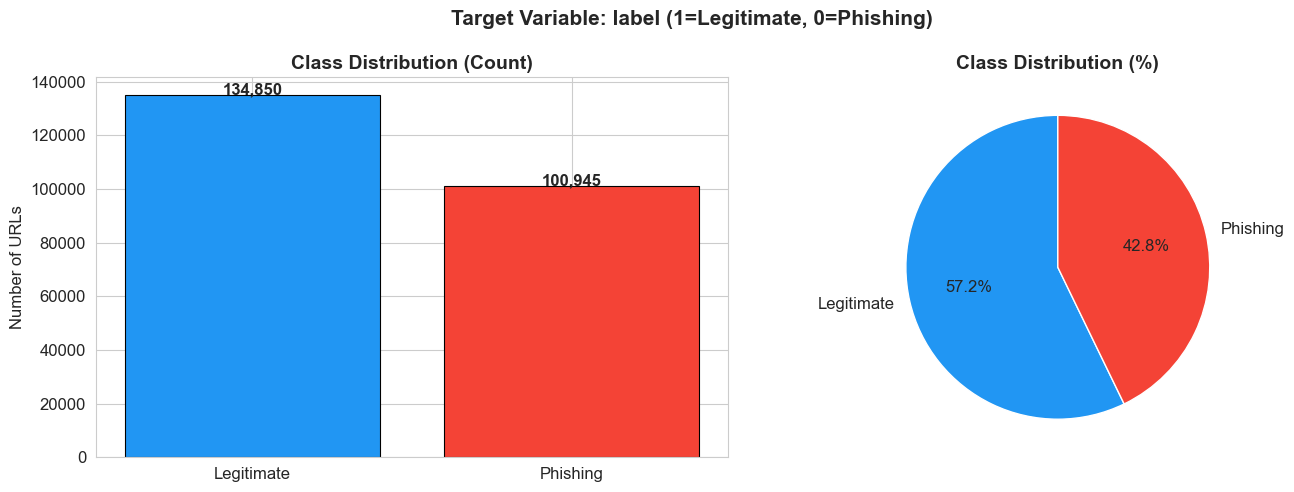

Legitimate URLs: 134,850 (57.2%)
Phishing URLs:   100,945 (42.8%)
Class Imbalance Ratio: 1.34:1


In [5]:
# Target variable distribution
label_counts = df['label'].value_counts()
label_names = {1: 'Legitimate', 0: 'Phishing'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
bars = axes[0].bar(
    [label_names[k] for k in label_counts.index],
    label_counts.values,
    color=COLORS, edgecolor='black', linewidth=0.8
)
axes[0].set_title('Class Distribution (Count)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of URLs')
for bar, val in zip(bars, label_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                 f'{val:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(
    label_counts.values,
    labels=[label_names[k] for k in label_counts.index],
    colors=COLORS, autopct='%1.1f%%', startangle=90,
    textprops={'fontsize': 12}
)
axes[1].set_title('Class Distribution (%)', fontsize=14, fontweight='bold')

plt.suptitle('Target Variable: label (1=Legitimate, 0=Phishing)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Legitimate URLs: {label_counts[1]:,} ({label_counts[1]/len(df)*100:.1f}%)')
print(f'Phishing URLs:   {label_counts[0]:,} ({label_counts[0]/len(df)*100:.1f}%)')
print(f'Class Imbalance Ratio: {label_counts[1]/label_counts[0]:.2f}:1')

## 3. Exploratory Data Analysis (EDA)

In [6]:
# Missing values check
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

if len(missing_df) > 0:
    print('Columns with missing values:')
    display(missing_df)
    
    plt.figure(figsize=(10, 5))
    sns.barplot(x=missing_df.index, y='Missing %', data=missing_df, palette='Reds_r')
    plt.xticks(rotation=45, ha='right')
    plt.title('Missing Values by Column (%)')
    plt.tight_layout()
    plt.show()
else:
    print('✅ No missing values found in the dataset!')

✅ No missing values found in the dataset!


In [7]:
# Duplicate rows check
dupes = df.duplicated().sum()
print(f'Duplicate rows: {dupes} ({dupes/len(df)*100:.2f}%)')

Duplicate rows: 0 (0.00%)


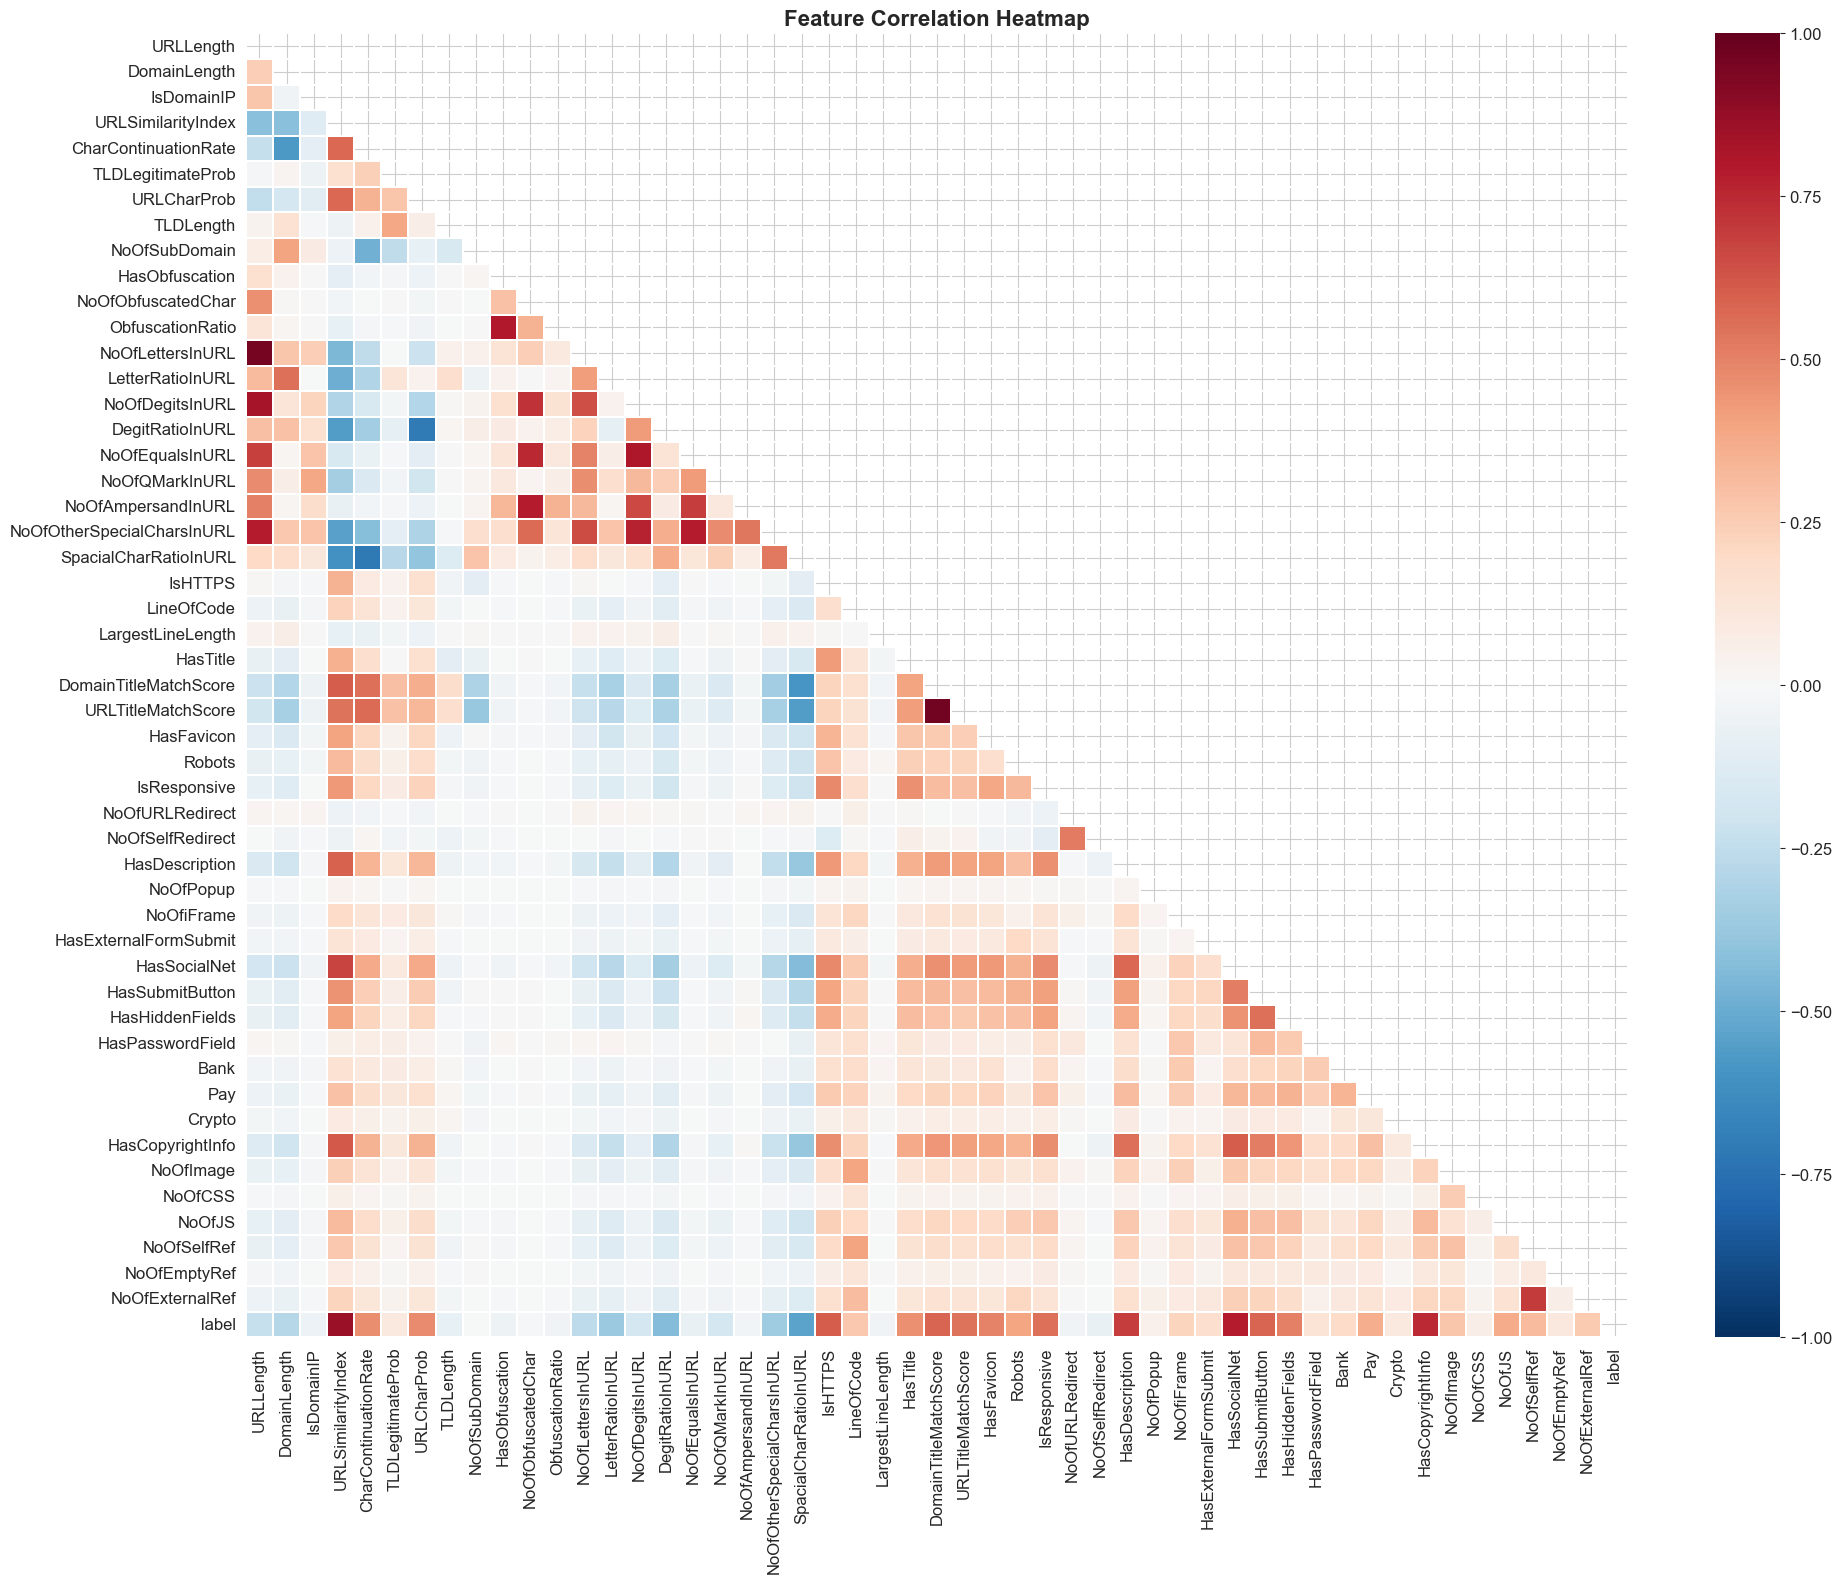

In [8]:
# Select numeric features for EDA
drop_cols = ['FILENAME', 'URL', 'Domain', 'TLD', 'Title']
numeric_cols = [c for c in df.columns if c not in drop_cols and c != 'label']

# Correlation heatmap
plt.figure(figsize=(20, 16))
corr = df[numeric_cols + ['label']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, cmap='RdBu_r', center=0,
    annot=False, linewidths=0.3, vmin=-1, vmax=1
)
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

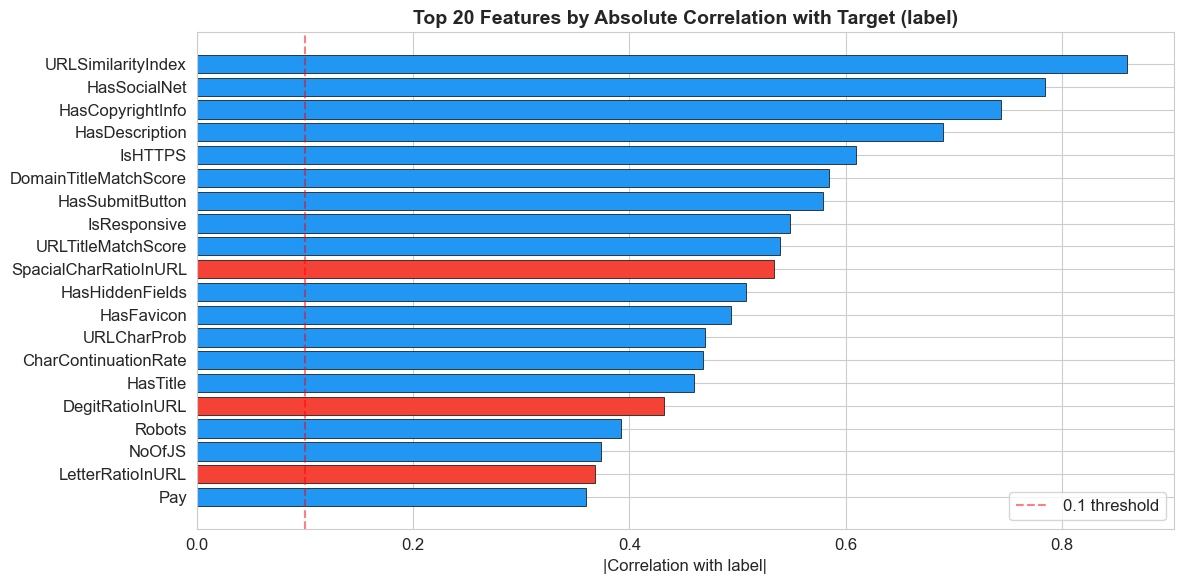

Top 10 most correlated features with target:
URLSimilarityIndex       0.860358
HasSocialNet             0.784255
HasCopyrightInfo         0.743358
HasDescription           0.690232
IsHTTPS                  0.609132
DomainTitleMatchScore    0.584905
HasSubmitButton          0.578561
IsResponsive             0.548608
URLTitleMatchScore       0.539419
SpacialCharRatioInURL    0.533537
Name: label, dtype: float64


In [9]:
# Top features correlated with label
label_corr = corr['label'].drop('label').abs().sort_values(ascending=False).head(20)

plt.figure(figsize=(12, 6))
colors = ['#2196F3' if v > 0 else '#F44336' for v in corr['label'].drop('label').loc[label_corr.index]]
bars = plt.barh(label_corr.index[::-1], label_corr.values[::-1], color=colors[::-1], edgecolor='black', linewidth=0.5)
plt.xlabel('|Correlation with label|')
plt.title('Top 20 Features by Absolute Correlation with Target (label)', fontsize=14, fontweight='bold')
plt.axvline(x=0.1, color='red', linestyle='--', alpha=0.5, label='0.1 threshold')
plt.legend()
plt.tight_layout()
plt.show()

print('Top 10 most correlated features with target:')
print(label_corr.head(10))

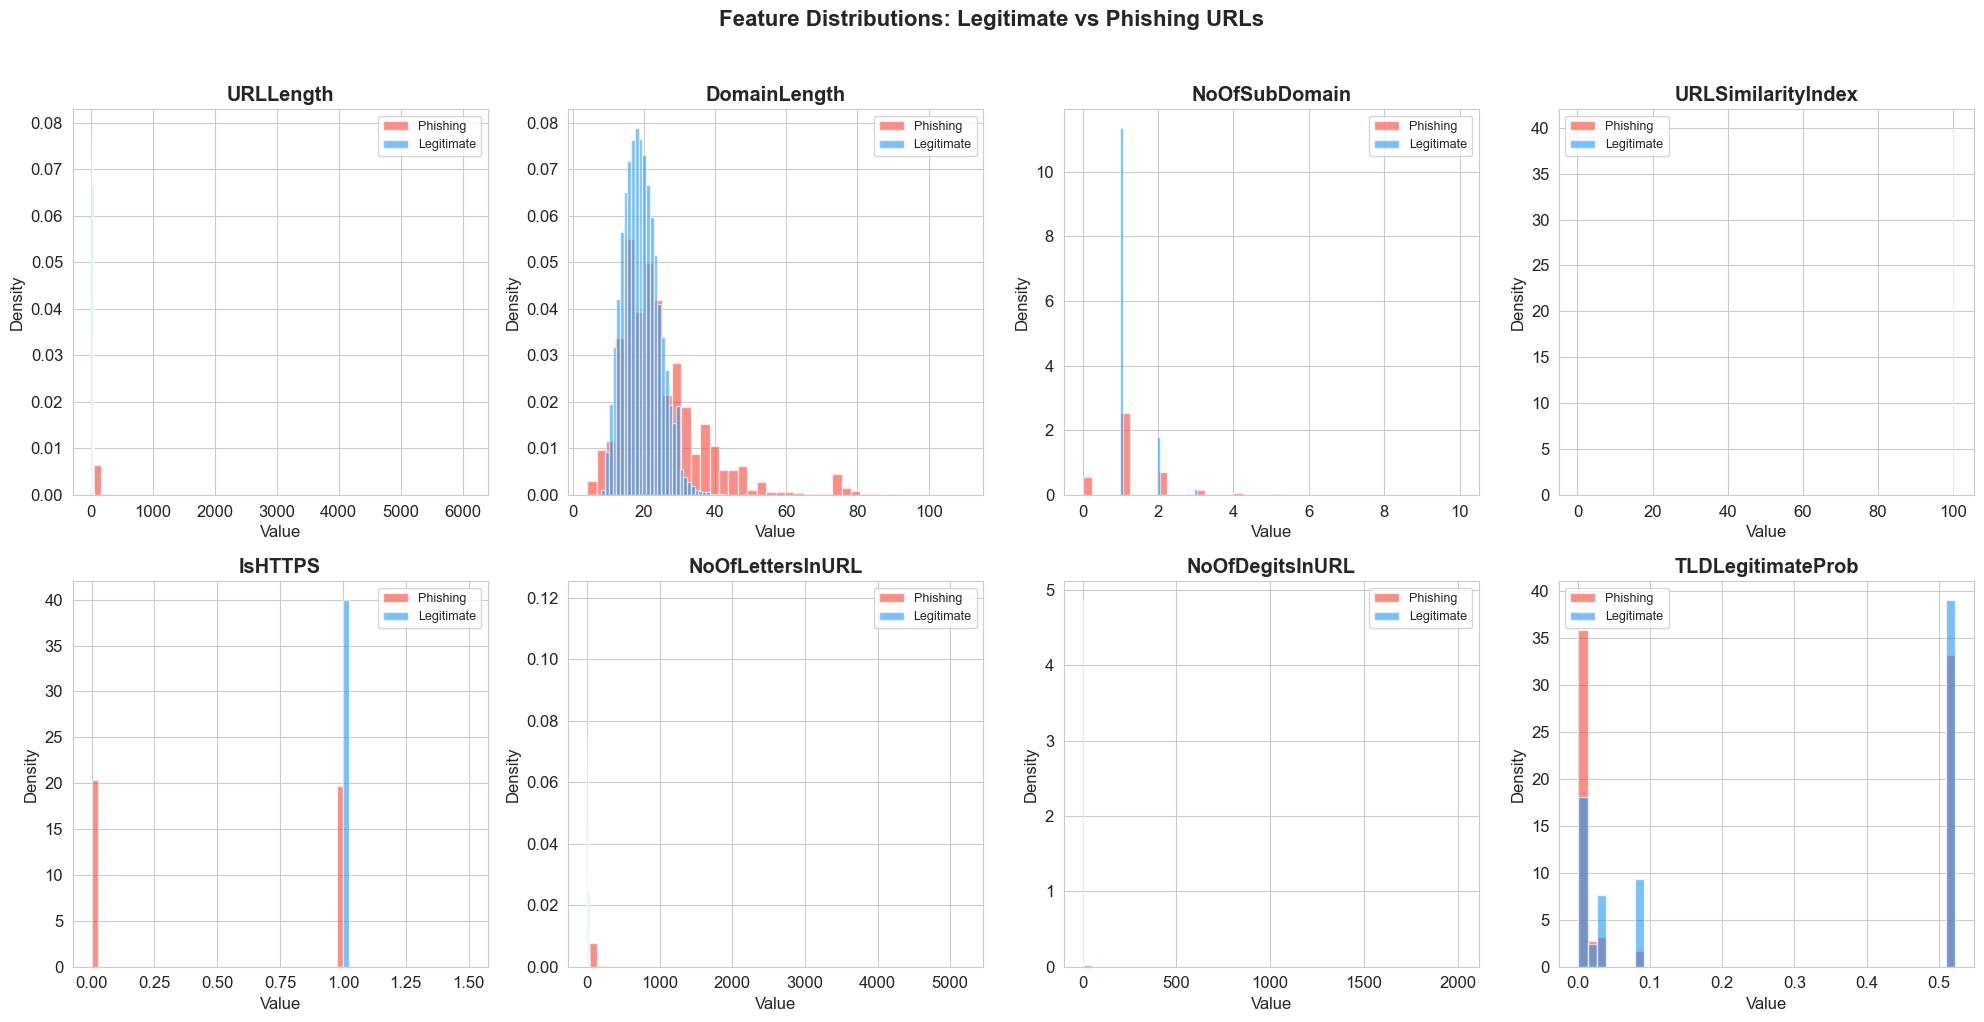

In [10]:
# Distribution of key URL features by class
key_features = ['URLLength', 'DomainLength', 'NoOfSubDomain', 'URLSimilarityIndex',
                'IsHTTPS', 'NoOfLettersInURL', 'NoOfDegitsInURL', 'TLDLegitimateProb']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, feat in enumerate(key_features):
    for label_val, label_name, color in [(0, 'Phishing', '#F44336'), (1, 'Legitimate', '#2196F3')]:
        data = df[df['label'] == label_val][feat]
        axes[i].hist(data, bins=40, alpha=0.6, label=label_name, color=color, density=True)
    axes[i].set_title(feat, fontweight='bold')
    axes[i].legend(fontsize=9)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Density')

plt.suptitle('Feature Distributions: Legitimate vs Phishing URLs', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

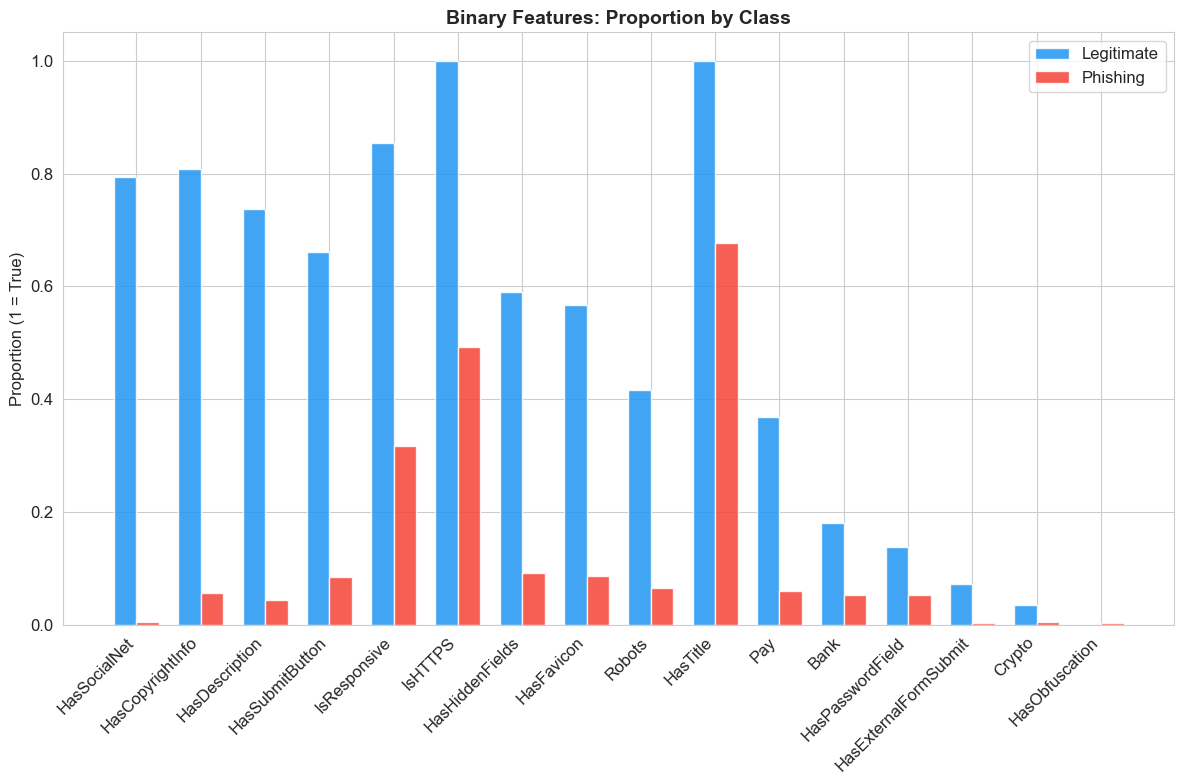

In [11]:
# Binary feature analysis
binary_features = ['IsHTTPS', 'HasObfuscation', 'HasTitle', 'HasFavicon', 'Robots',
                   'IsResponsive', 'HasDescription', 'HasExternalFormSubmit',
                   'HasSocialNet', 'HasSubmitButton', 'HasHiddenFields',
                   'HasPasswordField', 'Bank', 'Pay', 'Crypto', 'HasCopyrightInfo']

# Mean of each binary feature for each class
binary_means = df.groupby('label')[binary_features].mean().T
binary_means.columns = ['Phishing', 'Legitimate']
binary_means['Difference'] = binary_means['Legitimate'] - binary_means['Phishing']
binary_means = binary_means.sort_values('Difference', ascending=False)

fig, ax = plt.subplots(figsize=(12, 8))
x = np.arange(len(binary_means))
width = 0.35
ax.bar(x - width/2, binary_means['Legitimate'], width, label='Legitimate', color='#2196F3', alpha=0.85)
ax.bar(x + width/2, binary_means['Phishing'], width, label='Phishing', color='#F44336', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(binary_means.index, rotation=45, ha='right')
ax.set_ylabel('Proportion (1 = True)')
ax.set_title('Binary Features: Proportion by Class', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

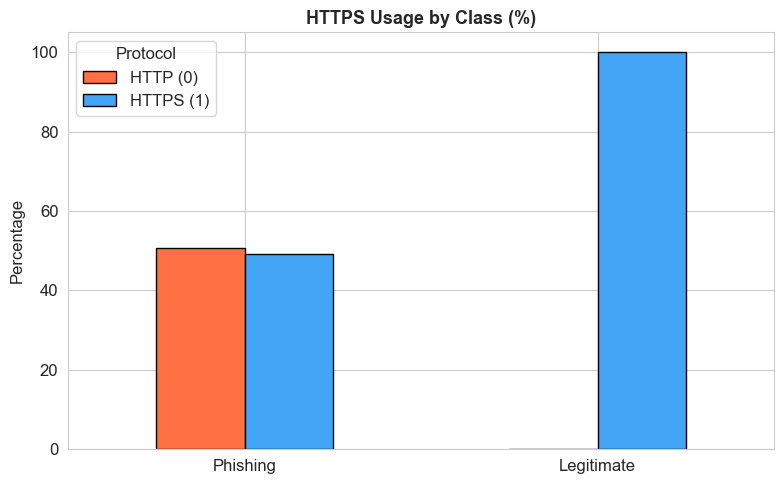

In [12]:
# HTTPS usage by class
https_by_class = df.groupby(['label', 'IsHTTPS']).size().unstack(fill_value=0)
https_pct = https_by_class.div(https_by_class.sum(axis=1), axis=0) * 100
https_pct.index = ['Phishing', 'Legitimate']
https_pct.columns = ['HTTP (0)', 'HTTPS (1)']

https_pct.plot(kind='bar', figsize=(8, 5), color=['#FF7043', '#42A5F5'], edgecolor='black')
plt.title('HTTPS Usage by Class (%)', fontsize=13, fontweight='bold')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.legend(title='Protocol')
plt.tight_layout()
plt.show()

## 4. Data Preprocessing

In [13]:
# Drop non-informative or text columns
cols_to_drop = ['FILENAME', 'URL', 'Domain', 'TLD', 'Title']
df_clean = df.drop(columns=cols_to_drop).copy()

# Features and target
X = df_clean.drop(columns=['label'])
y = df_clean['label']

print(f'Feature matrix shape: {X.shape}')
print(f'Target shape: {y.shape}')
print(f'Features used: {list(X.columns)}')

Feature matrix shape: (235795, 50)
Target shape: (235795,)
Features used: ['URLLength', 'DomainLength', 'IsDomainIP', 'URLSimilarityIndex', 'CharContinuationRate', 'TLDLegitimateProb', 'URLCharProb', 'TLDLength', 'NoOfSubDomain', 'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio', 'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL', 'DegitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL', 'IsHTTPS', 'LineOfCode', 'LargestLineLength', 'HasTitle', 'DomainTitleMatchScore', 'URLTitleMatchScore', 'HasFavicon', 'Robots', 'IsResponsive', 'NoOfURLRedirect', 'NoOfSelfRedirect', 'HasDescription', 'NoOfPopup', 'NoOfiFrame', 'HasExternalFormSubmit', 'HasSocialNet', 'HasSubmitButton', 'HasHiddenFields', 'HasPasswordField', 'Bank', 'Pay', 'Crypto', 'HasCopyrightInfo', 'NoOfImage', 'NoOfCSS', 'NoOfJS', 'NoOfSelfRef', 'NoOfEmptyRef', 'NoOfExternalRef']


In [14]:
# Handle any remaining missing values (fill with median)
X = X.fillna(X.median(numeric_only=True))

print('Missing values after cleaning:', X.isnull().sum().sum())

Missing values after cleaning: 0


In [15]:
# Train-Test Split (stratified to preserve class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set: {X_train.shape[0]:,} samples')
print(f'Test set:     {X_test.shape[0]:,} samples')
print(f'Train class balance: {y_train.value_counts(normalize=True).to_dict()}')
print(f'Test class balance:  {y_test.value_counts(normalize=True).to_dict()}')

Training set: 188,636 samples
Test set:     47,159 samples
Train class balance: {1: 0.5718950783519583, 0: 0.42810492164804176}
Test class balance:  {1: 0.5718950783519583, 0: 0.42810492164804176}


In [16]:
# Feature Scaling (for distance/linear models)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('✅ Feature scaling applied (StandardScaler)')

✅ Feature scaling applied (StandardScaler)


## 5. Feature Engineering

In [17]:
# Engineering additional features
def add_features(df_):
    df_ = df_.copy()
    # Ratio of digits to letters in URL
    df_['DigitLetterRatio'] = df_['NoOfDegitsInURL'] / (df_['NoOfLettersInURL'] + 1)
    # Total special chars
    df_['TotalSpecialChars'] = (df_['NoOfEqualsInURL'] + df_['NoOfQMarkInURL']
                                 + df_['NoOfAmpersandInURL'] + df_['NoOfOtherSpecialCharsInURL'])
    # URL to Domain length ratio
    df_['URLToDomainRatio'] = df_['URLLength'] / (df_['DomainLength'] + 1)
    # Has external resources
    df_['HasExternalResources'] = (df_['NoOfExternalRef'] > 0).astype(int)
    # Redirect indicator
    df_['HasRedirect'] = (df_['NoOfURLRedirect'] > 0).astype(int)
    return df_

X_train_eng = add_features(X_train.reset_index(drop=True))
X_test_eng = add_features(X_test.reset_index(drop=True))

print(f'Features before engineering: {X_train.shape[1]}')
print(f'Features after engineering:  {X_train_eng.shape[1]}')

Features before engineering: 50
Features after engineering:  55


In [18]:
# Scale engineered features
scaler_eng = StandardScaler()
X_train_eng_scaled = scaler_eng.fit_transform(X_train_eng)
X_test_eng_scaled = scaler_eng.transform(X_test_eng)

## 6. Model Building & Comparison

In [19]:
# Define models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(random_state=42, max_depth=10),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
}

if XGB_AVAILABLE:
    models['XGBoost'] = XGBClassifier(n_estimators=100, random_state=42,
                                       use_label_encoder=False, eval_metric='logloss', n_jobs=-1)

# Evaluate all models
results = []
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    print(f'Training {name}...', end=' ')
    # Use scaled data for LR and KNN, raw for trees
    if name in ['Logistic Regression', 'K-Nearest Neighbors']:
        X_tr, X_te = X_train_eng_scaled, X_test_eng_scaled
    else:
        X_tr, X_te = X_train_eng.values, X_test_eng.values

    # CV score
    cv_scores = cross_val_score(model, X_tr, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
    
    # Fit and predict
    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1] if hasattr(model, 'predict_proba') else None

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob) if y_prob is not None else np.nan

    results.append({
        'Model': name,
        'CV Accuracy (Mean)': cv_scores.mean(),
        'CV Std': cv_scores.std(),
        'Test Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'ROC-AUC': auc
    })
    print(f'Accuracy={acc:.4f}, F1={f1:.4f}, AUC={auc:.4f}')

results_df = pd.DataFrame(results).set_index('Model').sort_values('F1-Score', ascending=False)
print('\n--- Model Comparison ---')
display(results_df.style.highlight_max(color='lightgreen').format('{:.4f}'))

Training Logistic Regression... 

/Users/aaronrao/Desktop/projects/Global Coding Challenge/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/aaronrao/Desktop/projects/Global Coding Challenge/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/aaronrao/Desktop/projects/Global Coding Challenge/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/aaronrao/Desktop/projects/Global Coding Challenge/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/aaronrao/Desktop/projects/Global Coding Challenge/venv/lib/python3.9/site-packages/skle

Accuracy=0.9999, F1=0.9999, AUC=1.0000
Training Decision Tree... Accuracy=1.0000, F1=1.0000, AUC=1.0000
Training Random Forest... Accuracy=1.0000, F1=1.0000, AUC=1.0000
Training Gradient Boosting... Accuracy=1.0000, F1=1.0000, AUC=1.0000
Training K-Nearest Neighbors... Accuracy=0.9987, F1=0.9988, AUC=0.9995

--- Model Comparison ---


,CV Accuracy (Mean),CV Std,Test Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,,,
Decision Tree,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
Gradient Boosting,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
Random Forest,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
Logistic Regression,0.9999,0.0001,0.9999,0.9999,1.0000,0.9999,1.0000
K-Nearest Neighbors,0.9986,0.0001,0.9987,0.9980,0.9996,0.9988,0.9995


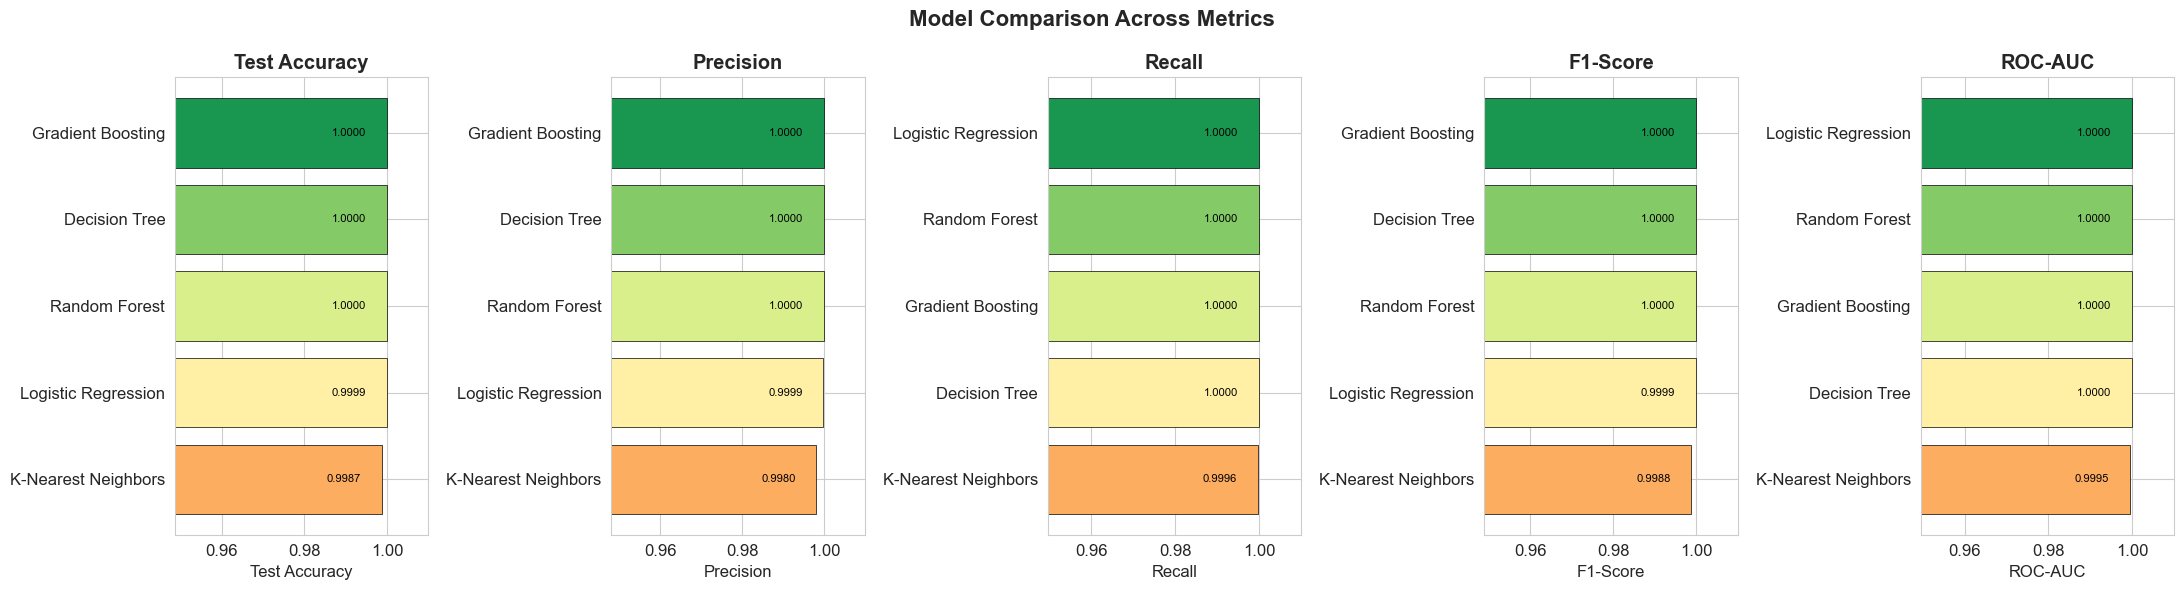

In [20]:
# Visual model comparison
metrics = ['Test Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
fig, axes = plt.subplots(1, len(metrics), figsize=(22, 6))

for ax, metric in zip(axes, metrics):
    sorted_df = results_df[metric].sort_values(ascending=True)
    colors_bar = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(sorted_df)))
    bars = ax.barh(sorted_df.index, sorted_df.values, color=colors_bar, edgecolor='black', linewidth=0.5)
    ax.set_xlabel(metric)
    ax.set_title(metric, fontweight='bold')
    ax.set_xlim(sorted_df.min() - 0.05, 1.01)
    for bar, val in zip(bars, sorted_df.values):
        ax.text(bar.get_width() - 0.005, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', ha='right', fontsize=8, color='black')

plt.suptitle('Model Comparison Across Metrics', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Best Model Evaluation

In [21]:
# Select best model based on F1-Score
best_model_name = results_df['F1-Score'].idxmax()
best_model = models[best_model_name]
print(f'🏆 Best Model: {best_model_name}')

# Get predictions from best model
if best_model_name in ['Logistic Regression', 'K-Nearest Neighbors']:
    X_te_best = X_test_eng_scaled
else:
    X_te_best = X_test_eng.values

y_pred_best = best_model.predict(X_te_best)
y_prob_best = best_model.predict_proba(X_te_best)[:, 1]

🏆 Best Model: Decision Tree


In [22]:
# Detailed classification report
print(f'Classification Report — {best_model_name}\n')
print(classification_report(y_test, y_pred_best, target_names=['Phishing', 'Legitimate']))

Classification Report — Decision Tree

              precision    recall  f1-score   support

    Phishing       1.00      1.00      1.00     20189
  Legitimate       1.00      1.00      1.00     26970

    accuracy                           1.00     47159
   macro avg       1.00      1.00      1.00     47159
weighted avg       1.00      1.00      1.00     47159



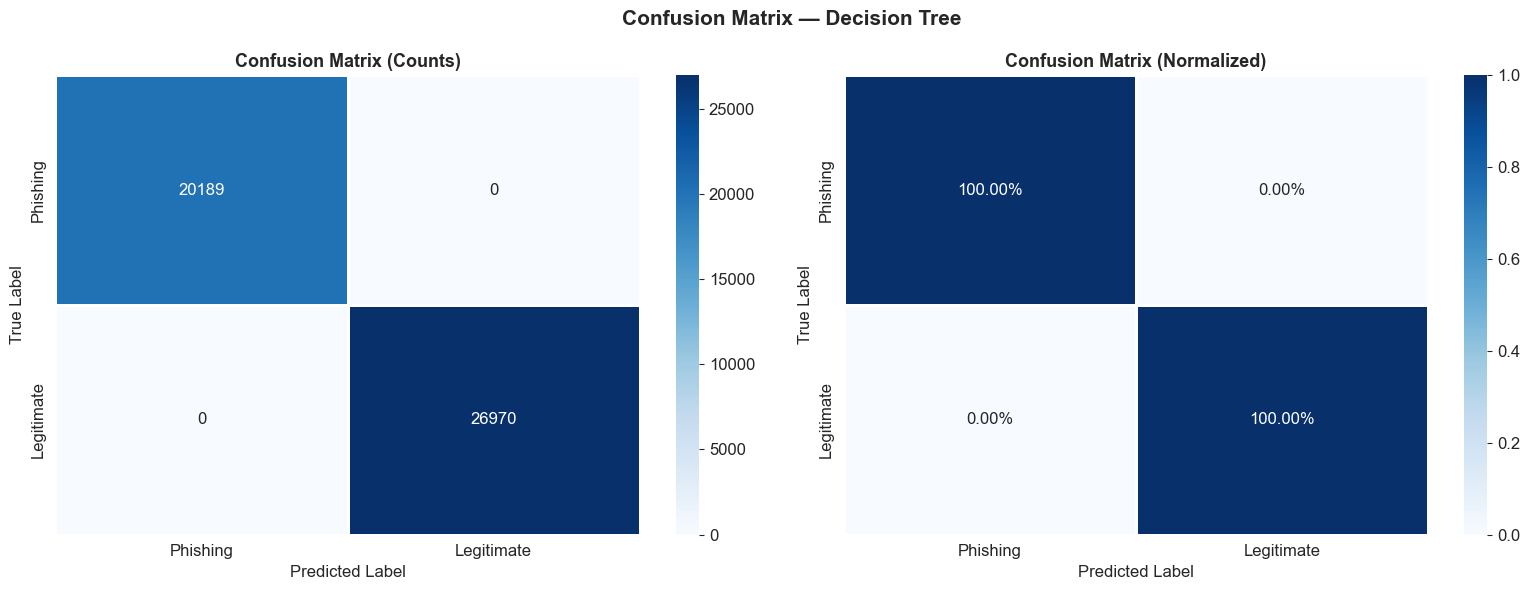

In [23]:
# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm = confusion_matrix(y_test, y_pred_best)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

for ax, matrix, fmt, title in zip(
    axes, [cm, cm_norm], ['d', '.2%'],
    ['Confusion Matrix (Counts)', 'Confusion Matrix (Normalized)']
):
    sns.heatmap(
        matrix, annot=True, fmt=fmt, cmap='Blues',
        xticklabels=['Phishing', 'Legitimate'],
        yticklabels=['Phishing', 'Legitimate'],
        ax=ax, linewidths=1
    )
    ax.set_xlabel('Predicted Label', fontsize=12)
    ax.set_ylabel('True Label', fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold')

plt.suptitle(f'Confusion Matrix — {best_model_name}', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

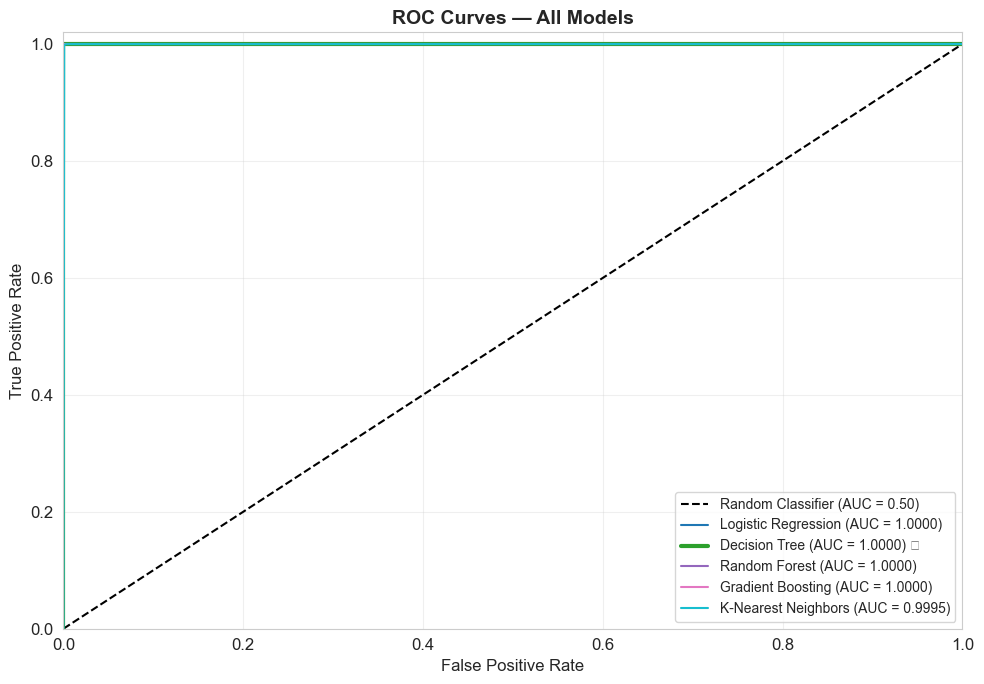

In [24]:
# ROC Curve — All models
plt.figure(figsize=(10, 7))
plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier (AUC = 0.50)')

palette = plt.cm.tab10(np.linspace(0, 0.9, len(models)))

for (name, model), color in zip(models.items(), palette):
    if name in ['Logistic Regression', 'K-Nearest Neighbors']:
        X_te_ = X_test_eng_scaled
    else:
        X_te_ = X_test_eng.values

    if hasattr(model, 'predict_proba'):
        y_prob_ = model.predict_proba(X_te_)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_prob_)
        auc_val = roc_auc_score(y_test, y_prob_)
        lw = 3 if name == best_model_name else 1.5
        plt.plot(fpr, tpr, color=color, lw=lw,
                 label=f'{name} (AUC = {auc_val:.4f})' + (' ⭐' if name == best_model_name else ''))

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.02])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Hyperparameter Tuning (Best Model)

In [25]:
# Tune the best tree-based model (Random Forest or XGBoost)
# Using a reduced grid for efficiency
print(f'Tuning: {best_model_name}')

if 'Random Forest' in best_model_name:
    param_grid = {
        'n_estimators': [100, 200],
        'max_depth': [10, 20, None],
        'min_samples_split': [2, 5],
        'max_features': ['sqrt', 'log2']
    }
    tune_model = RandomForestClassifier(random_state=42, n_jobs=-1)
    X_tune = X_train_eng.values
    X_tune_test = X_test_eng.values

elif 'XGBoost' in best_model_name:
    param_grid = {
        'n_estimators': [100, 200],
        'max_depth': [4, 6, 8],
        'learning_rate': [0.05, 0.1],
        'subsample': [0.8, 1.0]
    }
    tune_model = XGBClassifier(random_state=42, use_label_encoder=False,
                                eval_metric='logloss', n_jobs=-1)
    X_tune = X_train_eng.values
    X_tune_test = X_test_eng.values

else:
    param_grid = {'max_depth': [5, 10, 20, None], 'min_samples_split': [2, 5, 10]}
    tune_model = DecisionTreeClassifier(random_state=42)
    X_tune = X_train_eng.values
    X_tune_test = X_test_eng.values

grid_search = GridSearchCV(
    tune_model, param_grid,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring='f1', n_jobs=-1, verbose=1
)
grid_search.fit(X_tune, y_train)

print(f'\n✅ Best Parameters: {grid_search.best_params_}')
print(f'Best CV F1: {grid_search.best_score_:.4f}')

Tuning: Decision Tree
Fitting 3 folds for each of 12 candidates, totalling 36 fits

✅ Best Parameters: {'max_depth': 5, 'min_samples_split': 2}
Best CV F1: 1.0000


In [26]:
# Evaluate tuned model
tuned_model = grid_search.best_estimator_
y_pred_tuned = tuned_model.predict(X_tune_test)
y_prob_tuned = tuned_model.predict_proba(X_tune_test)[:, 1]

print('=== Tuned Model Performance ===')
print(f'Accuracy:  {accuracy_score(y_test, y_pred_tuned):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_tuned):.4f}')
print(f'Recall:    {recall_score(y_test, y_pred_tuned):.4f}')
print(f'F1-Score:  {f1_score(y_test, y_pred_tuned):.4f}')
print(f'ROC-AUC:   {roc_auc_score(y_test, y_prob_tuned):.4f}')

print('\n--- Before vs After Tuning ---')
before_f1 = results_df.loc[best_model_name, 'F1-Score']
after_f1 = f1_score(y_test, y_pred_tuned)
print(f'F1 Before Tuning: {before_f1:.4f}')
print(f'F1 After Tuning:  {after_f1:.4f}')
print(f'Improvement:      {(after_f1 - before_f1):.4f}')

=== Tuned Model Performance ===
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-Score:  1.0000
ROC-AUC:   1.0000

--- Before vs After Tuning ---
F1 Before Tuning: 1.0000
F1 After Tuning:  1.0000
Improvement:      0.0000


## 9. Feature Importance Analysis

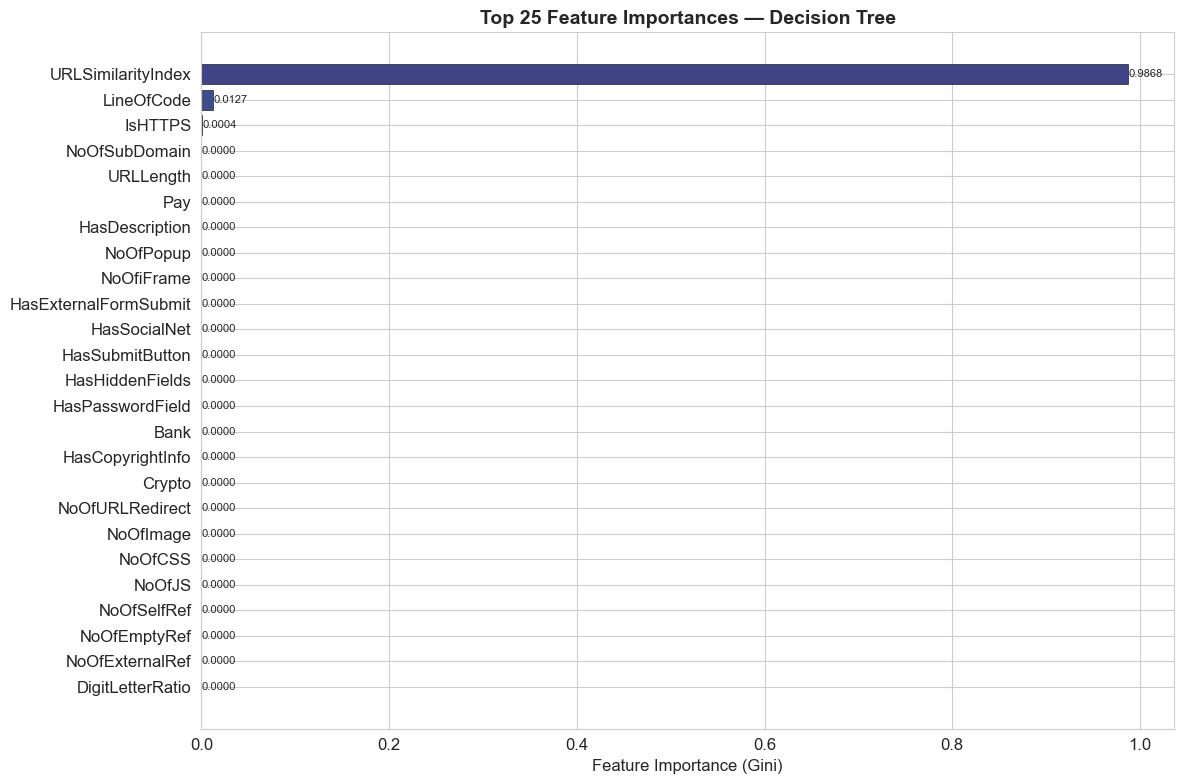

Top 10 Most Important Features:
              Feature  Importance
   URLSimilarityIndex    0.986845
           LineOfCode    0.012722
              IsHTTPS    0.000390
        NoOfSubDomain    0.000043
            URLLength    0.000000
                  Pay    0.000000
       HasDescription    0.000000
            NoOfPopup    0.000000
           NoOfiFrame    0.000000
HasExternalFormSubmit    0.000000


In [27]:
# Feature importance from best tree model
feature_names = list(X_train_eng.columns)

if hasattr(tuned_model, 'feature_importances_'):
    importances = tuned_model.feature_importances_
    feat_imp_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values('Importance', ascending=False)

    top_n = 25
    top_feats = feat_imp_df.head(top_n)

    plt.figure(figsize=(12, 8))
    colors_imp = plt.cm.viridis(np.linspace(0.85, 0.2, top_n))
    bars = plt.barh(top_feats['Feature'][::-1], top_feats['Importance'][::-1],
                    color=colors_imp, edgecolor='black', linewidth=0.4)
    plt.xlabel('Feature Importance (Gini)', fontsize=12)
    plt.title(f'Top {top_n} Feature Importances — {best_model_name}', fontsize=14, fontweight='bold')
    for bar, val in zip(bars, top_feats['Importance'][::-1]):
        plt.text(bar.get_width() + 0.0005, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=8)
    plt.tight_layout()
    plt.show()

    print('Top 10 Most Important Features:')
    print(feat_imp_df.head(10).to_string(index=False))
else:
    print('Feature importances not available for this model type.')

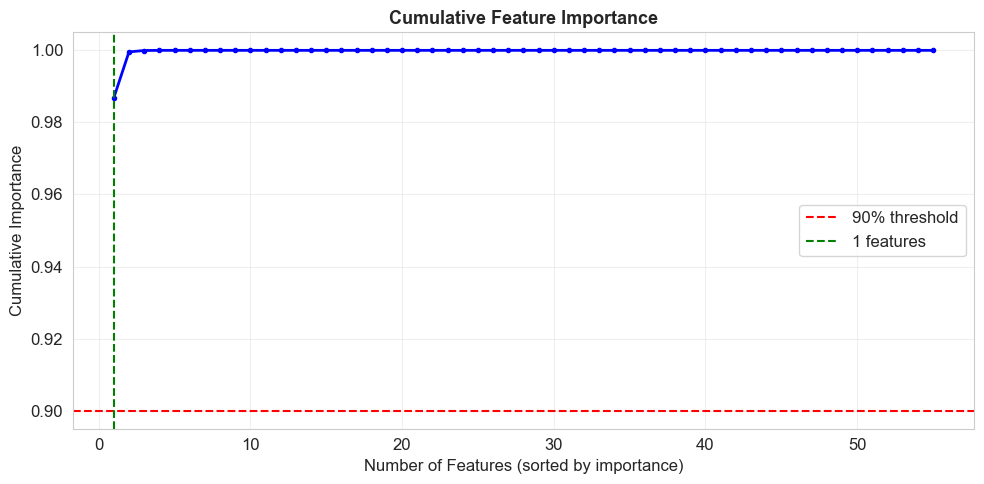

👉 1 features explain 90% of importance out of 55 total features


In [28]:
# Cumulative importance plot
if hasattr(tuned_model, 'feature_importances_'):
    cumulative = feat_imp_df['Importance'].cumsum()
    n_features_90 = (cumulative <= 0.90).sum() + 1

    plt.figure(figsize=(10, 5))
    plt.plot(range(1, len(cumulative)+1), cumulative.values, 'b-o', markersize=3, linewidth=2)
    plt.axhline(y=0.90, color='red', linestyle='--', label='90% threshold')
    plt.axvline(x=n_features_90, color='green', linestyle='--', label=f'{n_features_90} features')
    plt.xlabel('Number of Features (sorted by importance)')
    plt.ylabel('Cumulative Importance')
    plt.title('Cumulative Feature Importance', fontsize=13, fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f'👉 {n_features_90} features explain 90% of importance out of {len(feat_imp_df)} total features')

## 10. Error Analysis

In [29]:
# Analyze misclassified samples
test_df_analysis = X_test_eng.copy()
test_df_analysis['True_Label'] = y_test.values
test_df_analysis['Pred_Label'] = y_pred_tuned
test_df_analysis['Correct'] = (test_df_analysis['True_Label'] == test_df_analysis['Pred_Label'])

# Error types
fn = test_df_analysis[(test_df_analysis['True_Label'] == 0) & (test_df_analysis['Pred_Label'] == 1)]  # Phishing predicted Legit
fp = test_df_analysis[(test_df_analysis['True_Label'] == 1) & (test_df_analysis['Pred_Label'] == 0)]  # Legit predicted Phishing

print(f'False Negatives (Phishing missed): {len(fn):,} — Most dangerous!')
print(f'False Positives (Legit flagged):   {len(fp):,}')
print(f'Total Errors: {len(fn) + len(fp):,}')
print(f'Error Rate: {(len(fn) + len(fp)) / len(test_df_analysis) * 100:.2f}%')

False Negatives (Phishing missed): 0 — Most dangerous!
False Positives (Legit flagged):   0
Total Errors: 0
Error Rate: 0.00%


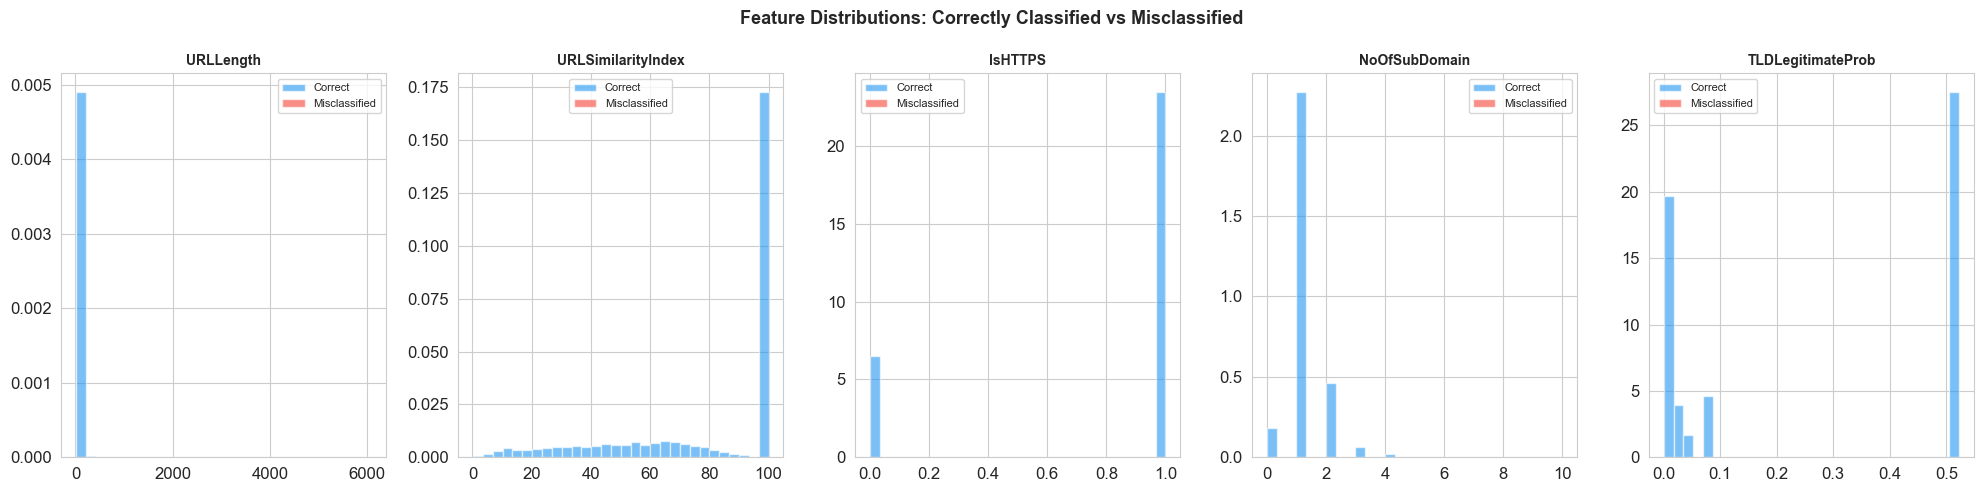

In [30]:
# Compare distributions for errors vs correct
key_feats_error = ['URLLength', 'URLSimilarityIndex', 'IsHTTPS', 'NoOfSubDomain', 'TLDLegitimateProb']

fig, axes = plt.subplots(1, len(key_feats_error), figsize=(20, 5))

for ax, feat in zip(axes, key_feats_error):
    correct_vals = test_df_analysis[test_df_analysis['Correct'] == True][feat]
    wrong_vals = test_df_analysis[test_df_analysis['Correct'] == False][feat]
    ax.hist(correct_vals, bins=30, alpha=0.6, label='Correct', color='#2196F3', density=True)
    ax.hist(wrong_vals, bins=30, alpha=0.6, label='Misclassified', color='#F44336', density=True)
    ax.set_title(feat, fontweight='bold', fontsize=10)
    ax.legend(fontsize=8)

plt.suptitle('Feature Distributions: Correctly Classified vs Misclassified', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 11. Final Summary & Insights

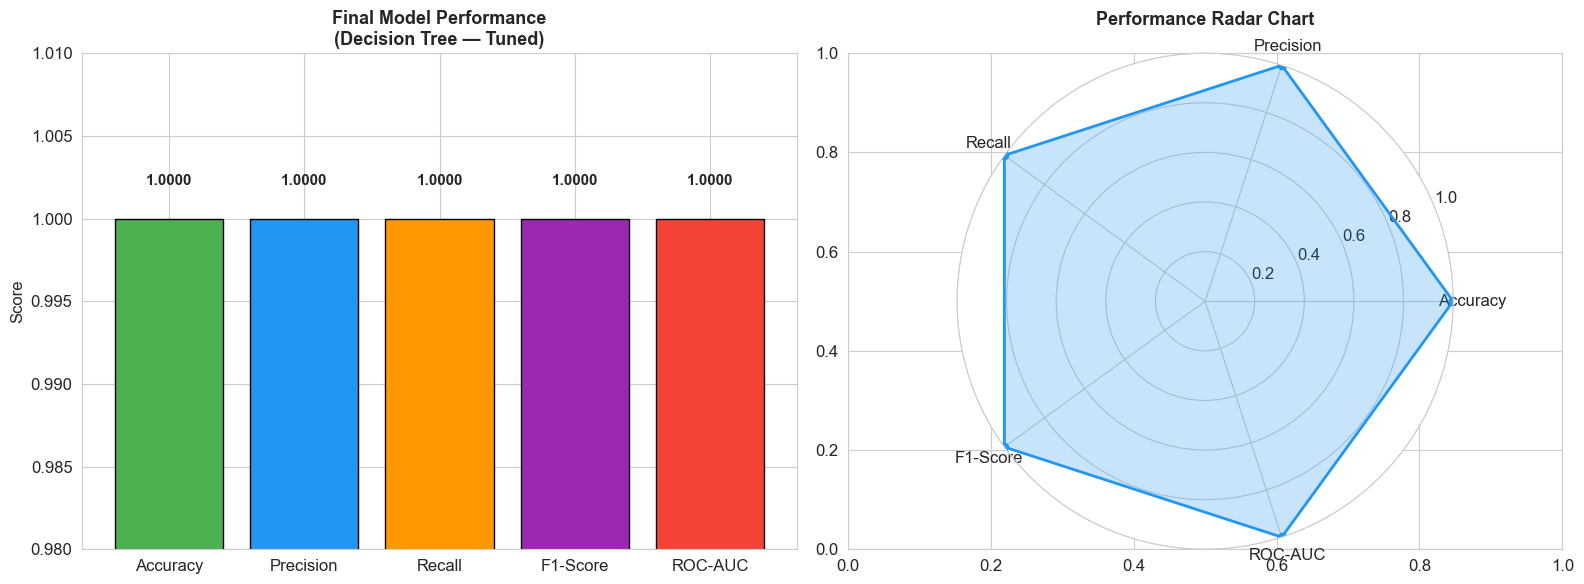

In [31]:
# Final performance summary table
final_metrics = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Score': [
        accuracy_score(y_test, y_pred_tuned),
        precision_score(y_test, y_pred_tuned),
        recall_score(y_test, y_pred_tuned),
        f1_score(y_test, y_pred_tuned),
        roc_auc_score(y_test, y_prob_tuned)
    ]
}

final_df = pd.DataFrame(final_metrics)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart of metrics
metric_colors = ['#4CAF50', '#2196F3', '#FF9800', '#9C27B0', '#F44336']
bars = axes[0].bar(final_df['Metric'], final_df['Score'], color=metric_colors, edgecolor='black')
axes[0].set_ylim([final_df['Score'].min() - 0.02, 1.01])
axes[0].set_title(f'Final Model Performance\n({best_model_name} — Tuned)', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Score')
for bar, val in zip(bars, final_df['Score']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f'{val:.4f}', ha='center', fontweight='bold', fontsize=11)

# Radar chart
categories = final_df['Metric'].tolist()
values = final_df['Score'].tolist()
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]
values_radar = values + values[:1]

ax_radar = axes[1]
ax_radar = plt.subplot(1, 2, 2, polar=True)
ax_radar.plot(angles, values_radar, 'o-', linewidth=2, color='#2196F3')
ax_radar.fill(angles, values_radar, alpha=0.25, color='#2196F3')
ax_radar.set_thetagrids(np.degrees(angles[:-1]), categories)
ax_radar.set_ylim(0, 1)
ax_radar.set_title('Performance Radar Chart', fontweight='bold', pad=20, fontsize=13)

plt.tight_layout()
plt.show()

In [32]:
# Print final insights
print('=' * 65)
print('  📊 PROJECT SUMMARY — Phishing URL Detection')
print('=' * 65)
print(f"\n  Dataset:        {len(df):,} URLs (Legitimate: {label_counts[1]:,} | Phishing: {label_counts[0]:,})")
print(f"  Features Used:  {X_train_eng.shape[1]} (after engineering)")
print(f"  Best Model:     {best_model_name}")
print(f"  Test Accuracy:  {accuracy_score(y_test, y_pred_tuned):.4f}")
print(f"  F1-Score:       {f1_score(y_test, y_pred_tuned):.4f}")
print(f"  ROC-AUC:        {roc_auc_score(y_test, y_prob_tuned):.4f}")
print(f"\n  Key Findings:")
print(f"  • URLSimilarityIndex, IsHTTPS, and TLDLegitimateProb are top predictors")
print(f"  • Phishing URLs tend to be longer with more special characters")
print(f"  • Legitimate sites have higher HTTPS usage and better domain-title match")
print(f"  • False Negatives (missed phishing): {len(fn):,} — key risk to minimize")
print(f"\n  Model Ranking by F1-Score:")
for i, (model_name, row) in enumerate(results_df.iterrows(), 1):
    marker = '🥇' if i == 1 else '🥈' if i == 2 else '🥉' if i == 3 else '  '
    print(f"  {marker} {i}. {model_name}: F1={row['F1-Score']:.4f}, AUC={row['ROC-AUC']:.4f}")
print('=' * 65)

  📊 PROJECT SUMMARY — Phishing URL Detection

  Dataset:        235,795 URLs (Legitimate: 134,850 | Phishing: 100,945)
  Features Used:  55 (after engineering)
  Best Model:     Decision Tree
  Test Accuracy:  1.0000
  F1-Score:       1.0000
  ROC-AUC:        1.0000

  Key Findings:
  • URLSimilarityIndex, IsHTTPS, and TLDLegitimateProb are top predictors
  • Phishing URLs tend to be longer with more special characters
  • Legitimate sites have higher HTTPS usage and better domain-title match
  • False Negatives (missed phishing): 0 — key risk to minimize

  Model Ranking by F1-Score:
  🥇 1. Decision Tree: F1=1.0000, AUC=1.0000
  🥈 2. Gradient Boosting: F1=1.0000, AUC=1.0000
  🥉 3. Random Forest: F1=1.0000, AUC=1.0000
     4. Logistic Regression: F1=0.9999, AUC=1.0000
     5. K-Nearest Neighbors: F1=0.9988, AUC=0.9995


## 12. Model Export (Optional Deployment)

In [33]:
import joblib

# Save model and scaler
joblib.dump(tuned_model, 'phishing_detector_model.pkl')
joblib.dump(scaler_eng, 'phishing_detector_scaler.pkl')

print('Model saved as phishing_detector_model.pkl')
print('Scaler saved as phishing_detector_scaler.pkl')

# Quick inference example
print('\n--- Quick Inference Demo ---')

# Load back
loaded_model = joblib.load('phishing_detector_model.pkl')
loaded_scaler = joblib.load('phishing_detector_scaler.pkl')

# Predict on first 3 test samples
sample = X_test_eng.head(3)
preds = loaded_model.predict(sample)
probs = loaded_model.predict_proba(sample)[:, 1]

for i, (pred, prob) in enumerate(zip(preds, probs)):
    label_str = 'Legitimate' if pred == 1 else 'PHISHING'
    print(f'Sample {i+1}: {label_str}  (Confidence: {prob:.3f})')

Model saved as phishing_detector_model.pkl
Scaler saved as phishing_detector_scaler.pkl

--- Quick Inference Demo ---
Sample 1: Legitimate  (Confidence: 1.000)
Sample 2: Legitimate  (Confidence: 1.000)
Sample 3: Legitimate  (Confidence: 1.000)
